In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import torch
print(torch.cuda.is_available())

True


In [3]:
!pip install segmentation-models-pytorch albumentations opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.3 MB/s eta 0:00:00


In [4]:
import segmentation_models_pytorch as smp

NUM_CLASSES = 6

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

model = model.cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [5]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mapping = {0:0, 1:1, 2:2, 3:3, 27:4, 39:5}

        mask = np.vectorize(mapping.get)(mask)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).long()

        return image, mask

In [6]:
train_img_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/train/Color_Images"
train_mask_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/train/Segmentation"

val_img_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/val/Color_Images"
val_mask_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/val/Segmentation"

In [7]:
dataset = SegmentationDataset(train_img_dir, train_mask_dir)

print("Total samples:", len(dataset))

img, mask = dataset[0]
print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

Total samples: 2857
Image shape: torch.Size([3, 540, 960])
Mask shape: torch.Size([540, 960])


In [8]:
import albumentations as A

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=30, p=0.5),
])

val_transform = A.Compose([
    A.Resize(256, 256)
])

In [9]:
train_dataset = SegmentationDataset(
    train_img_dir,
    train_mask_dir,
    transform=train_transform
)

val_dataset = SegmentationDataset(
    val_img_dir,
    val_mask_dir,
    transform=val_transform
)

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    drop_last=True
)

In [11]:
for images, masks in train_loader:
    print("Images:", images.shape)
    print("Masks:", masks.shape)
    break

Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 256, 256])


In [12]:
import segmentation_models_pytorch as smp

loss_fn = smp.losses.DiceLoss(mode='multiclass')

In [13]:
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [15]:
print(device)

cuda


In [16]:
import numpy as np

mask = dataset[0][1].numpy()
print(np.unique(mask))

[0 1 2 3 4 5]


In [ ]:
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone copy this

"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

plt.switch_backend('Agg')


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img, 0, -1)
    img = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

value_map = {
    0: 0,        # background
    100: 1,      # Trees
    200: 2,      # Lush Bushes
    300: 3,      # Dry Grass
    500: 4,      # Dry Bushes
    550: 5,      # Ground Clutter
    700: 6,      # Logs
    800: 7,      # Rocks
    7100: 8,     # Landscape
    10000: 9     # Sky
}
n_classes = len(value_map)


def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)


# ============================================================================
# Dataset
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)

        mask_path = os.path.join(self.masks_dir, data_id)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask)
            mask = (mask * 255).long()

        return image, mask

# ============================================================================
# DATASET + DATALOADER SETUP
# ============================================================================

train_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/train"
val_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/val"

# Transforms
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((448, 448), interpolation=Image.NEAREST),
    transforms.ToTensor()
])

# Dataset
train_dataset = MaskDataset(train_data_dir, transform, mask_transform)
val_dataset = MaskDataset(val_data_dir, transform, mask_transform)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    drop_last=True
)

print(" DataLoader Ready")

# ============================================================================
# LOAD DINOv2 BACKBONE
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
backbone = backbone.to(device)
backbone.eval()


# ============================================================================
# Model: Segmentation Head (ConvNeXt-style)
# ============================================================================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)

tokenW, tokenH = 32, 32

model = SegmentationHeadConvNeXt(
    in_channels=384,
    out_channels=n_classes,
    tokenW=tokenW,
    tokenH=tokenH
).to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/Seg_model_refined.pth"))
print(" Old model loaded successfully")
# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10, ignore_index=255):
    """Compute IoU for each class and return mean IoU."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    iou_per_class = []
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue

        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append((intersection / union).cpu().numpy())

    return np.nanmean(iou_per_class)


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    """Compute Dice coefficient (F1 Score) per class and return mean Dice Score."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    dice_per_class = []
    for class_id in range(num_classes):
        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        dice_score = (2. * intersection + smooth) / (pred_inds.sum().float() + target_inds.sum().float() + smooth)

        dice_per_class.append(dice_score.cpu().numpy())

    return np.mean(dice_per_class)


def compute_pixel_accuracy(pred, target):
    """Compute pixel accuracy."""
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == target).float().mean().cpu().numpy()


def evaluate_metrics(model, backbone, data_loader, device, num_classes=10, show_progress=True):
    """Evaluate all metrics on a dataset."""
    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    model.eval()
    loader = tqdm(data_loader, desc="Evaluating", leave=False, unit="batch") if show_progress else data_loader
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            output = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = model(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

# ============================================================================
# TRAINING SETUP
# ============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 10
best_iou = 0.4

print("🚀 Training Started...")

for epoch in range(num_epochs):

    #  TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.squeeze(1).to(device)

        with torch.no_grad():
            features = backbone.forward_features(images)["x_norm_patchtokens"]

        outputs = model(features)
        outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    #  VALIDATION
    model.eval()
    val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.squeeze(1).to(device)

            features = backbone.forward_features(images)["x_norm_patchtokens"]
            outputs = model(features)
            outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

            val_iou += compute_iou(outputs, masks, num_classes=n_classes)

    val_iou = val_iou / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss:.4f} | IoU: {val_iou:.4f}")
    scheduler.step()

    #  SAVE BEST MODEL
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/content/drive/MyDrive/Seg_model_refined.pth")
        print("✅ Best model saved!")

✅ DataLoader Ready


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Old model loaded successfully
🚀 Training Started...
Epoch [1/10] | Loss: 146.7767 | IoU: 0.4772
✅ Best model saved!
Epoch [2/10] | Loss: 146.2974 | IoU: 0.4779
✅ Best model saved!
Epoch [3/10] | Loss: 145.7762 | IoU: 0.4805
✅ Best model saved!
Epoch [4/10] | Loss: 145.4078 | IoU: 0.4826
✅ Best model saved!
Epoch [5/10] | Loss: 144.9880 | IoU: 0.4770
Epoch [6/10] | Loss: 144.1723 | IoU: 0.4830
✅ Best model saved!
Epoch [7/10] | Loss: 143.9957 | IoU: 0.4862
✅ Best model saved!
Epoch [8/10] | Loss: 143.7821 | IoU: 0.4855
Epoch [9/10] | Loss: 143.5512 | IoU: 0.4827
Epoch [10/10] | Loss: 143.4107 | IoU: 0.4880
✅ Best model saved!


In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/Seg_model_refined.pth"))
print("✅ Previous trained model loaded")
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

NameError: name 'model' is not defined

In [ ]:
loss = [
    143.6782, 143.3863, 143.0497, 142.7618, 142.5865,
    142.2178, 141.8560, 141.7026, 141.5887, 141.2402,
    141.0052, 140.8091, 140.8479, 140.4295, 140.1222
]

iou = [
    0.4853, 0.4917, 0.4848, 0.4893, 0.4874,
    0.4877, 0.4912, 0.4888, 0.4925, 0.4930,
    0.4903, 0.4901, 0.4899, 0.4945, 0.4914
]


In [ ]:
num_epochs = 15
best_iou = 0.488

print("🚀 Refinement Training Started...")

for epoch in range(num_epochs):

    # 🔵 TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.squeeze(1).to(device)

        with torch.no_grad():
            features = backbone.forward_features(images)["x_norm_patchtokens"]

        outputs = model(features)
        outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    #  VALIDATION
    model.eval()
    val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.squeeze(1).to(device)

            features = backbone.forward_features(images)["x_norm_patchtokens"]
            outputs = model(features)
            outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

            val_iou += compute_iou(outputs, masks, num_classes=n_classes)

    val_iou = val_iou / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss:.4f} | IoU: {val_iou:.4f}")
    scheduler.step()

    #  SAVE BEST MODEL
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/content/drive/MyDrive/Seg_model_refined.pth")
        print(" Best refined model saved!")

🚀 Refinement Training Started...
Epoch [1/15] | Loss: 143.6782 | IoU: 0.4853
Epoch [2/15] | Loss: 143.3863 | IoU: 0.4917
✅ Best refined model saved!
Epoch [3/15] | Loss: 143.0497 | IoU: 0.4848
Epoch [4/15] | Loss: 142.7618 | IoU: 0.4893
Epoch [5/15] | Loss: 142.5865 | IoU: 0.4874
Epoch [6/15] | Loss: 142.2178 | IoU: 0.4877
Epoch [7/15] | Loss: 141.8560 | IoU: 0.4912
Epoch [8/15] | Loss: 141.7026 | IoU: 0.4888
Epoch [9/15] | Loss: 141.5887 | IoU: 0.4925
✅ Best refined model saved!
Epoch [10/15] | Loss: 141.2402 | IoU: 0.4930
✅ Best refined model saved!
Epoch [11/15] | Loss: 141.0052 | IoU: 0.4903
Epoch [12/15] | Loss: 140.8091 | IoU: 0.4901
Epoch [13/15] | Loss: 140.8479 | IoU: 0.4899
Epoch [14/15] | Loss: 140.4295 | IoU: 0.4945
✅ Best refined model saved!
Epoch [15/15] | Loss: 140.1222 | IoU: 0.4914


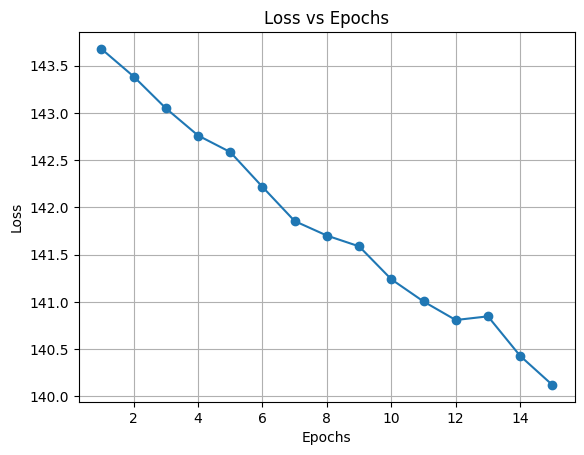

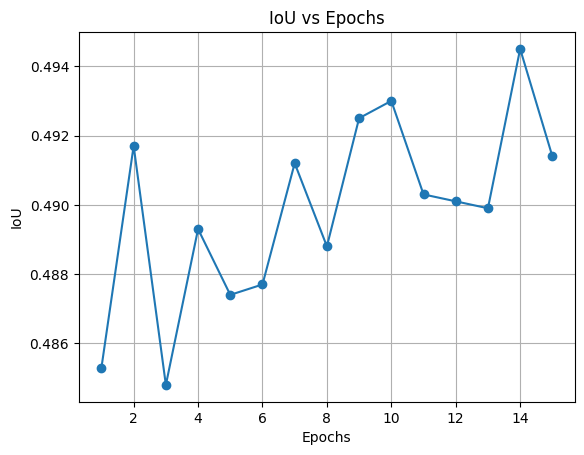

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 16))

# -------- Loss Graph --------
plt.figure()
plt.plot(epochs, loss, marker='o')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# -------- IoU Graph --------
plt.figure()
plt.plot(epochs, iou, marker='o')
plt.title("IoU vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.grid()
plt.show()

In [ ]:
!unzip -o dataset.zip

unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [ ]:
!python test_segmentation.py \
--model_path "/drive/MyDrive/Seg_model_refined.pth" \
--data_dir "/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages" \
--output_dir "/predictions" \
--batch_size 2

python3: can't open file '/content/test_segmentation.py': [Errno 2] No such file or directory


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import cv2

# =========================
# MODEL
# =========================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, 10, 1)

    def forward(self, x):
        B, N, C = x.shape


        x = x.reshape(B, self.H, self.W, C)
        x = x.permute(0, 3, 1, 2)

        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)


# =========================
# CONFIG
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/drive/MyDrive/Seg_model_refined.pth"
test_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
output_dir = "/content/predictions"

os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD MODEL
# =========================

print(" Loading model...")

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
backbone = backbone.to(device)
backbone.eval()


model = SegmentationHeadConvNeXt(384, 10, 16, 16).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(" Model loaded successfully")

# =========================
# TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# COLOR MAP
# =========================

color_palette = np.array([
    [0, 0, 0],
    [34, 139, 34],
    [0, 255, 0],
    [210, 180, 140],
    [139, 90, 43],
    [128, 128, 0],
    [139, 69, 19],
    [128, 128, 128],
    [160, 82, 45],
    [135, 206, 235],
], dtype=np.uint8)

def mask_to_color(mask):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for i in range(10):
        color_mask[mask == i] = color_palette[i]
    return color_mask

# =========================
# TEST LOOP
# =========================

print(" Running inference...")

image_files = os.listdir(test_dir)


image_files = image_files[:5]

for i, img_name in enumerate(image_files):
    print(f"Processing {i+1}/{len(image_files)} → {img_name}")

    img_path = os.path.join(test_dir, img_name)

    try:
        image = Image.open(img_path).convert("RGB")
    except:
        continue

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = backbone.forward_features(input_tensor)["x_norm_patchtokens"]
        output = model(features)
        output = F.interpolate(output, size=(224,224), mode="bilinear")

    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    color_mask = mask_to_color(pred_mask)

    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR))

print(" All predictions saved in:", output_dir)

 Loading model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


 Model loaded successfully
 Running inference...
Processing 1/5 → 0000082.png
Processing 2/5 → 0000092.png
Processing 3/5 → 0000112.png
Processing 4/5 → 0000118.png
Processing 5/5 → 0000105.png
 All predictions saved in: /content/predictions


Available images: ['0000112.png', '0000118.png', '0000082.png', '0000105.png', '0000092.png']


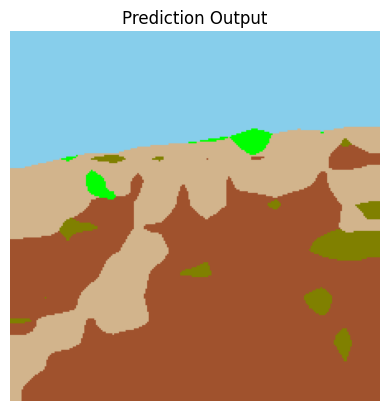

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "/content/predictions"

files = [f for f in os.listdir(pred_dir) if f.endswith((".png", ".jpg"))]

print("Available images:", files[:5])

img = Image.open(os.path.join(pred_dir, files[0]))

plt.imshow(img)
plt.axis('off')
plt.title("Prediction Output")
plt.show()

Prediction files: ['0000112.png', '0000118.png', '0000082.png', '0000105.png', '0000092.png']


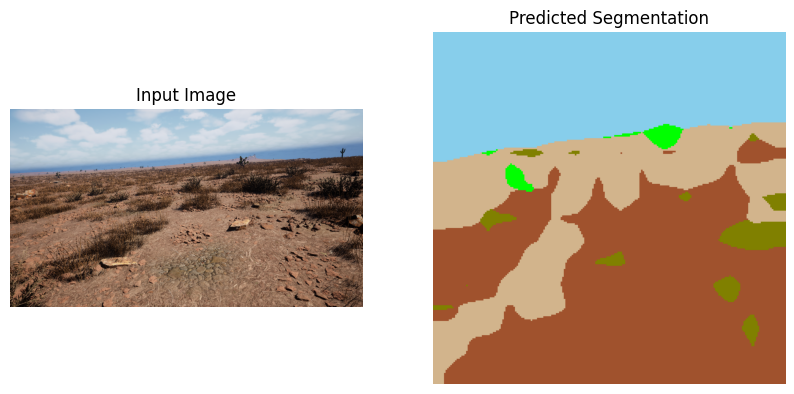

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

input_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
pred_dir = "/content/predictions"


pred_files = [f for f in os.listdir(pred_dir) if f.endswith(".png")]

print("Prediction files:", pred_files[:5])


img_name = pred_files[0]


input_img = Image.open(os.path.join(input_dir, img_name))
pred_img = Image.open(os.path.join(pred_dir, img_name))


fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(input_img)
ax[0].set_title("Input Image")

ax[1].imshow(pred_img)
ax[1].set_title("Predicted Segmentation")

for a in ax:
    a.axis('off')

plt.show()

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path


input_folder = "/content/predictions"

output_folder = os.path.join(input_folder, "colorized")
os.makedirs(output_folder, exist_ok=True)

image_extensions = ['.png', '.jpg', '.jpeg']
image_files = [f for f in Path(input_folder).iterdir()
               if f.is_file() and f.suffix.lower() in image_extensions]

print(f"Found {len(image_files)} image files")

color_map = {}

for image_file in sorted(image_files):
    print(f"Processing: {image_file.name}")

    im = cv2.imread(str(image_file), cv2.IMREAD_UNCHANGED)

    if im is None:
        continue


    if len(im.shape) == 3:
        print("  Skipped (already color image)")
        continue


    unique_vals = np.unique(im)

    im2 = np.zeros((im.shape[0], im.shape[1], 3), dtype=np.uint8)

    for v in unique_vals:
        if v not in color_map:
            color_map[v] = np.random.randint(0, 255, (3,), dtype=np.uint8)

        im2[im == v] = color_map[v]

    output_path = os.path.join(output_folder, image_file.name)
    cv2.imwrite(output_path, im2)

    print(f"  Saved: {output_path}")

print("\n Done! Colorized masks saved in:", output_folder)

Found 5 image files
Processing: 0000082.png
  Skipped (already color image)
Processing: 0000092.png
  Skipped (already color image)
Processing: 0000105.png
  Skipped (already color image)
Processing: 0000112.png
  Skipped (already color image)
Processing: 0000118.png
  Skipped (already color image)

 Done! Colorized masks saved in: /content/predictions/colorized


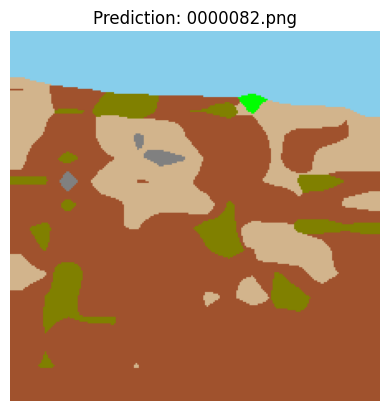

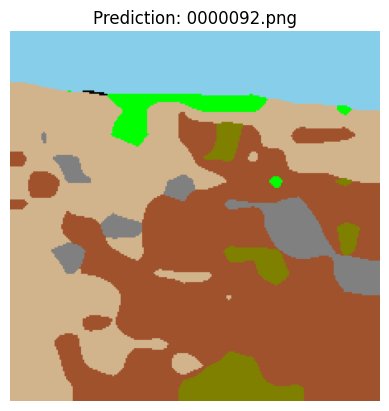

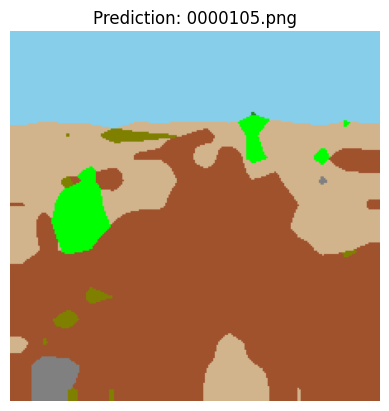

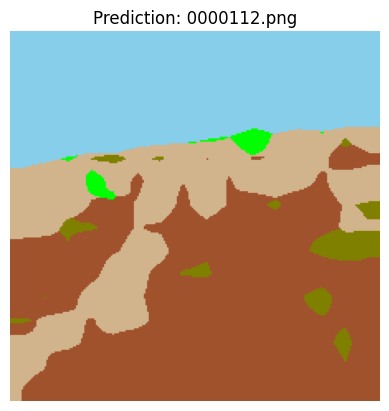

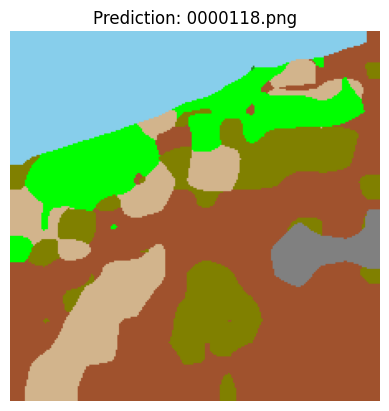

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

pred_dir = "/content/predictions"

files = sorted(os.listdir(pred_dir))[:5]

for f in files:
    img = Image.open(os.path.join(pred_dir, f))
    plt.imshow(img)
    plt.title(f"Prediction: {f}")
    plt.axis('off')
    plt.show()

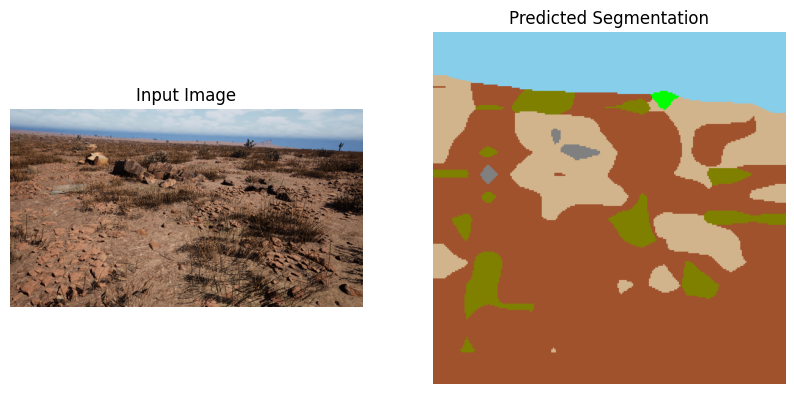

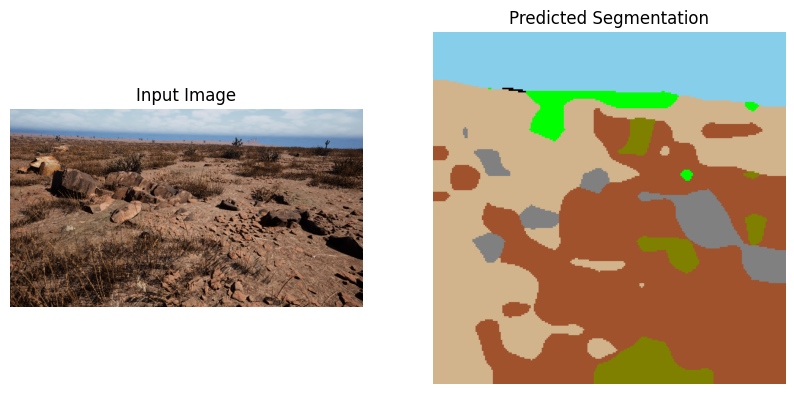

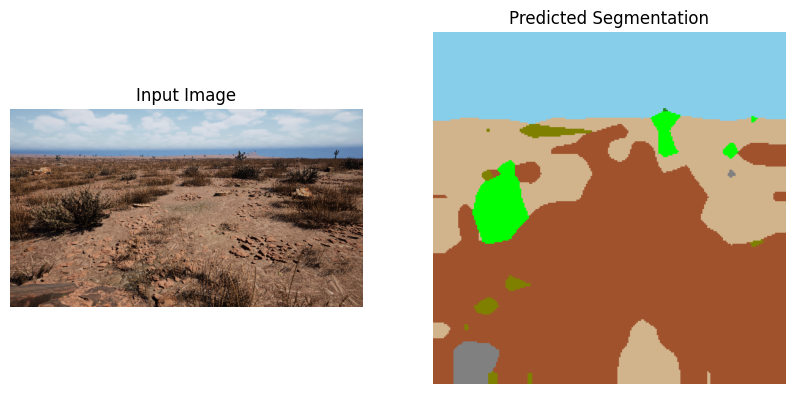

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

input_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
pred_dir = "/content/predictions"

files = sorted(os.listdir(pred_dir))[:3]

for f in files:
    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    input_img = Image.open(os.path.join(input_dir, f))
    pred_img = Image.open(os.path.join(pred_dir, f))

    ax[0].imshow(input_img)
    ax[0].set_title("Input Image")
    ax[0].axis('off')

    ax[1].imshow(pred_img)
    ax[1].set_title("Predicted Segmentation")
    ax[1].axis('off')

    plt.show()

In [18]:
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone copy this

"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

plt.switch_backend('Agg')


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img, 0, -1)
    img = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

value_map = {
    0: 0,        # background
    100: 1,      # Trees
    200: 2,      # Lush Bushes
    300: 3,      # Dry Grass
    500: 4,      # Dry Bushes
    550: 5,      # Ground Clutter
    700: 6,      # Logs
    800: 7,      # Rocks
    7100: 8,     # Landscape
    10000: 9     # Sky
}
n_classes = len(value_map)

def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)


# ============================================================================
# Dataset
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)

        mask_path = os.path.join(self.masks_dir, data_id)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask)
            mask = (mask * 255).long()

        return image, mask

# ============================================================================
# DATASET + DATALOADER SETUP
# ============================================================================

train_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/train"
val_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/val"

# Transforms
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((448, 448), interpolation=Image.NEAREST),
    transforms.ToTensor()
])

# Dataset
train_dataset = MaskDataset(train_data_dir, transform, mask_transform)
val_dataset = MaskDataset(val_data_dir, transform, mask_transform)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    drop_last=True
)

print(" DataLoader Ready")

# ============================================================================
# LOAD DINOv2 BACKBONE
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
backbone = backbone.to(device)
backbone.eval()


# ============================================================================
# Model: Segmentation Head (ConvNeXt-style)
# ============================================================================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)

tokenW, tokenH = 32, 32

model = SegmentationHeadConvNeXt(
    in_channels=384,
    out_channels=n_classes,
    tokenW=tokenW,
    tokenH=tokenH
).to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/Seg_model_refined.pth"))
print(" Old model loaded successfully")
# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10, ignore_index=255):
    """Compute IoU for each class and return mean IoU."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    iou_per_class = []
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue

        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append((intersection / union).cpu().numpy())

    return np.nanmean(iou_per_class)


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    """Compute Dice coefficient (F1 Score) per class and return mean Dice Score."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    dice_per_class = []
    for class_id in range(num_classes):
        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        dice_score = (2. * intersection + smooth) / (pred_inds.sum().float() + target_inds.sum().float() + smooth)

        dice_per_class.append(dice_score.cpu().numpy())

    return np.mean(dice_per_class)


def compute_pixel_accuracy(pred, target):
    """Compute pixel accuracy."""
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == target).float().mean().cpu().numpy()


def evaluate_metrics(model, backbone, data_loader, device, num_classes=10, show_progress=True):
    """Evaluate all metrics on a dataset."""
    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    model.eval()
    loader = tqdm(data_loader, desc="Evaluating", leave=False, unit="batch") if show_progress else data_loader
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            output = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = model(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

# ============================================================================
# TRAINING SETUP
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=10).permute(0,3,1,2).float()

        intersection = (preds * targets_one_hot).sum(dim=(2,3))
        union = preds.sum(dim=(2,3)) + targets_one_hot.sum(dim=(2,3))

        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        return 1 - dice.mean()

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):
    return ce_loss(pred, target) + dice_loss(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 15
best_iou = 0.49

print(" Training Started...")

for epoch in range(num_epochs):

    #  TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.squeeze(1).to(device)

        with torch.no_grad():
            features = backbone.forward_features(images)["x_norm_patchtokens"]

        outputs = model(features)
        outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    #  VALIDATION
    model.eval()
    val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.squeeze(1).to(device)

            features = backbone.forward_features(images)["x_norm_patchtokens"]
            outputs = model(features)
            outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

            val_iou += compute_iou(outputs, masks, num_classes=n_classes)

    val_iou = val_iou / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss:.4f} | IoU: {val_iou:.4f}")
    scheduler.step()

    #  SAVE BEST MODEL
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/content/drive/MyDrive/Seg_model_refined.pth")
        print(" Best model saved!")

 DataLoader Ready
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 163MB/s]


 Old model loaded successfully
 Training Started...
Epoch [1/15] | Loss: 561.3754 | IoU: 0.3267
Epoch [2/15] | Loss: 514.1961 | IoU: 0.3173


KeyboardInterrupt: 

In [2]:
loss = [
    139.7693, 139.5252, 139.4081, 139.2891, 139.1696,
    138.6676, 138.6136, 138.5050, 138.4431, 138.3884,
    138.1590, 138.1317, 138.1031, 138.0466, 138.0286
]

iou = [
    0.4949, 0.4970, 0.4931, 0.4921, 0.4972,
    0.4951, 0.4936, 0.4957, 0.4948, 0.4945,
    0.4956, 0.4968, 0.4972, 0.4962, 0.4967
]

In [19]:
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone copy this

"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

plt.switch_backend('Agg')


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img, 0, -1)
    img = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

value_map = {
    0: 0,        # background
    100: 1,      # Trees
    200: 2,      # Lush Bushes
    300: 3,      # Dry Grass
    500: 4,      # Dry Bushes
    550: 5,      # Ground Clutter
    700: 6,      # Logs
    800: 7,      # Rocks
    7100: 8,     # Landscape
    10000: 9     # Sky
}
n_classes = len(value_map)


def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)


# ============================================================================
# Dataset
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)

        mask_path = os.path.join(self.masks_dir, data_id)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask)
            mask = (mask * 255).long()

        return image, mask

# ============================================================================
# DATASET + DATALOADER SETUP
# ============================================================================

train_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/train"
val_data_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_Training_Dataset/val"

# Transforms
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((448, 448), interpolation=Image.NEAREST),
    transforms.ToTensor()
])

# Dataset
train_dataset = MaskDataset(train_data_dir, transform, mask_transform)
val_dataset = MaskDataset(val_data_dir, transform, mask_transform)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    drop_last=True
)

print(" DataLoader Ready")

# ============================================================================
# LOAD DINOv2 BACKBONE
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
backbone = backbone.to(device)
backbone.eval()


# ============================================================================
# Model: Segmentation Head (ConvNeXt-style)
# ============================================================================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)

tokenW, tokenH = 32, 32

model = SegmentationHeadConvNeXt(
    in_channels=384,
    out_channels=n_classes,
    tokenW=tokenW,
    tokenH=tokenH
).to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/Seg_model_refined.pth"))
print(" Old model loaded successfully")
# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10, ignore_index=255):
    """Compute IoU for each class and return mean IoU."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    iou_per_class = []
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue

        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append((intersection / union).cpu().numpy())

    return np.nanmean(iou_per_class)


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    """Compute Dice coefficient (F1 Score) per class and return mean Dice Score."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    dice_per_class = []
    for class_id in range(num_classes):
        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        dice_score = (2. * intersection + smooth) / (pred_inds.sum().float() + target_inds.sum().float() + smooth)

        dice_per_class.append(dice_score.cpu().numpy())

    return np.mean(dice_per_class)


def compute_pixel_accuracy(pred, target):
    """Compute pixel accuracy."""
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == target).float().mean().cpu().numpy()


def evaluate_metrics(model, backbone, data_loader, device, num_classes=10, show_progress=True):
    """Evaluate all metrics on a dataset."""
    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    model.eval()
    loader = tqdm(data_loader, desc="Evaluating", leave=False, unit="batch") if show_progress else data_loader
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            output = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = model(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

# ============================================================================
# TRAINING SETUP
# ============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 15
best_iou = 0.49

print("🚀 Training Started...")

for epoch in range(num_epochs):

    #  TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.squeeze(1).to(device)

        with torch.no_grad():
            features = backbone.forward_features(images)["x_norm_patchtokens"]

        outputs = model(features)
        outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    #  VALIDATION
    model.eval()
    val_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.squeeze(1).to(device)

            features = backbone.forward_features(images)["x_norm_patchtokens"]
            outputs = model(features)
            outputs = F.interpolate(outputs, size=images.shape[2:], mode="bilinear", align_corners=False)

            val_iou += compute_iou(outputs, masks, num_classes=n_classes)

    val_iou = val_iou / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss:.4f} | IoU: {val_iou:.4f}")
    scheduler.step()

    #  SAVE BEST MODEL
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/content/drive/MyDrive/Seg_model_refined.pth")
        print(" Best model saved!")

 DataLoader Ready


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


 Old model loaded successfully
🚀 Training Started...
Epoch [1/15] | Loss: 139.7693 | IoU: 0.4949
 Best model saved!
Epoch [2/15] | Loss: 139.5252 | IoU: 0.4970
 Best model saved!
Epoch [3/15] | Loss: 139.4081 | IoU: 0.4931
Epoch [4/15] | Loss: 139.2891 | IoU: 0.4921
Epoch [5/15] | Loss: 139.1696 | IoU: 0.4972
 Best model saved!
Epoch [6/15] | Loss: 138.6676 | IoU: 0.4951
Epoch [7/15] | Loss: 138.6136 | IoU: 0.4936
Epoch [8/15] | Loss: 138.5050 | IoU: 0.4957
Epoch [9/15] | Loss: 138.4431 | IoU: 0.4948
Epoch [10/15] | Loss: 138.3884 | IoU: 0.4945
Epoch [11/15] | Loss: 138.1590 | IoU: 0.4956
Epoch [12/15] | Loss: 138.1317 | IoU: 0.4968
Epoch [13/15] | Loss: 138.1031 | IoU: 0.4972
 Best model saved!
Epoch [14/15] | Loss: 138.0466 | IoU: 0.4962
Epoch [15/15] | Loss: 138.0286 | IoU: 0.4967


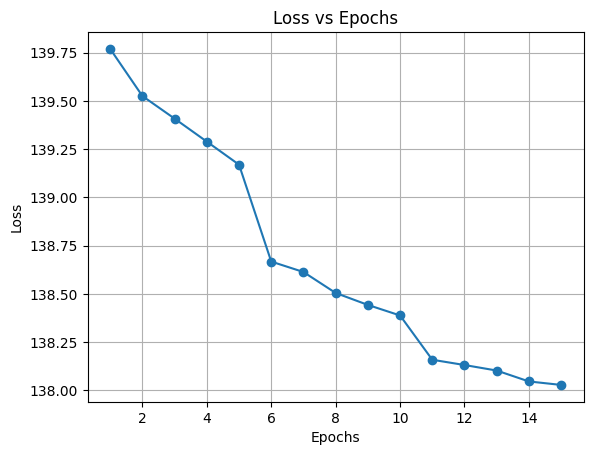

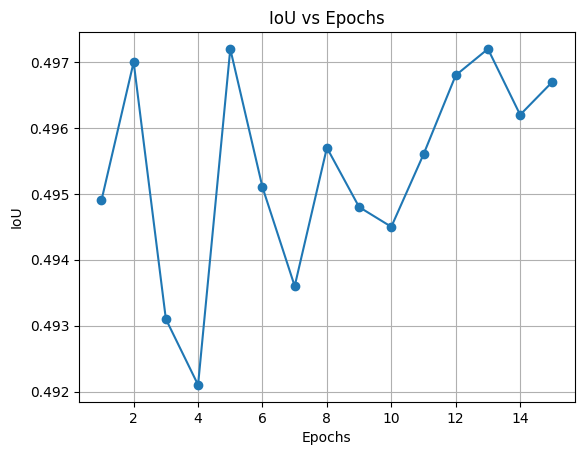

In [3]:
import matplotlib.pyplot as plt

epochs = list(range(1, 16))

# -------- Loss Graph --------
plt.figure()
plt.plot(epochs, loss, marker='o')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# -------- IoU Graph --------
plt.figure()
plt.plot(epochs, iou, marker='o')
plt.title("IoU vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.grid()
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import cv2

# =========================
# MODEL
# =========================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, 10, 1)

    def forward(self, x):
        B, N, C = x.shape


        x = x.reshape(B, self.H, self.W, C)
        x = x.permute(0, 3, 1, 2)

        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)


# =========================
# CONFIG
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/drive/MyDrive/Seg_model_refined.pth"
test_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
output_dir = "/content/predictions"

os.makedirs(output_dir, exist_ok=True)

# =========================
# LOAD MODEL
# =========================

print(" Loading model...")

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
backbone = backbone.to(device)
backbone.eval()


model = SegmentationHeadConvNeXt(384, 10, 16, 16).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(" Model loaded successfully")

# =========================
# TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# COLOR MAP
# =========================

color_palette = np.array([
    [0, 0, 0],
    [34, 139, 34],
    [0, 255, 0],
    [210, 180, 140],
    [139, 90, 43],
    [128, 128, 0],
    [139, 69, 19],
    [128, 128, 128],
    [160, 82, 45],
    [135, 206, 235],
], dtype=np.uint8)

def mask_to_color(mask):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for i in range(10):
        color_mask[mask == i] = color_palette[i]
    return color_mask

# =========================
# TEST LOOP
# =========================

print(" Running inference...")

image_files = os.listdir(test_dir)


image_files = image_files[:5]

for i, img_name in enumerate(image_files):
    print(f"Processing {i+1}/{len(image_files)} → {img_name}")

    img_path = os.path.join(test_dir, img_name)

    try:
        image = Image.open(img_path).convert("RGB")
    except:
        continue

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = backbone.forward_features(input_tensor)["x_norm_patchtokens"]
        output = model(features)
        output = F.interpolate(output, size=(224,224), mode="bilinear")

    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    color_mask = mask_to_color(pred_mask)

    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR))

print(" All predictions saved in:", output_dir)

 Loading model...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 239MB/s]


 Model loaded successfully
 Running inference...
Processing 1/5 → 0000082.png
Processing 2/5 → 0000092.png
Processing 3/5 → 0000112.png
Processing 4/5 → 0000118.png
Processing 5/5 → 0000105.png
 All predictions saved in: /content/predictions


Available images: ['0000092.png', '0000118.png', '0000082.png', '0000105.png', '0000112.png']


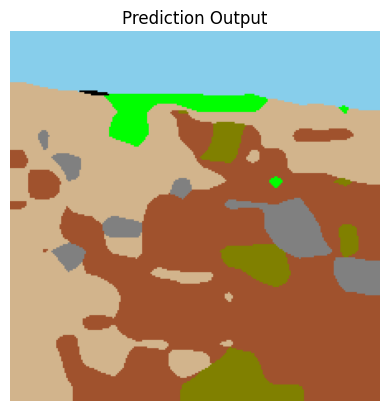

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "/content/predictions"

files = [f for f in os.listdir(pred_dir) if f.endswith((".png", ".jpg"))]

print("Available images:", files[:5])

img = Image.open(os.path.join(pred_dir, files[0]))

plt.imshow(img)
plt.axis('off')
plt.title("Prediction Output")
plt.show()

Prediction files: ['0000092.png', '0000118.png', '0000082.png', '0000105.png', '0000112.png']


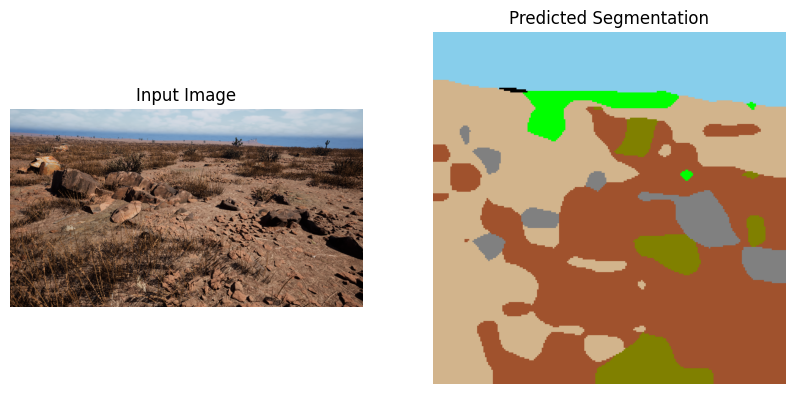

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

input_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
pred_dir = "/content/predictions"


pred_files = [f for f in os.listdir(pred_dir) if f.endswith(".png")]

print("Prediction files:", pred_files[:5])


img_name = pred_files[0]


input_img = Image.open(os.path.join(input_dir, img_name))
pred_img = Image.open(os.path.join(pred_dir, img_name))


fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(input_img)
ax[0].set_title("Input Image")

ax[1].imshow(pred_img)
ax[1].set_title("Predicted Segmentation")

for a in ax:
    a.axis('off')

plt.show()

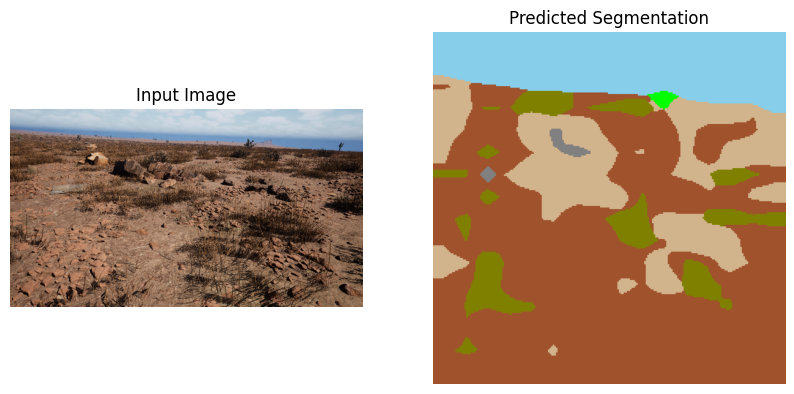

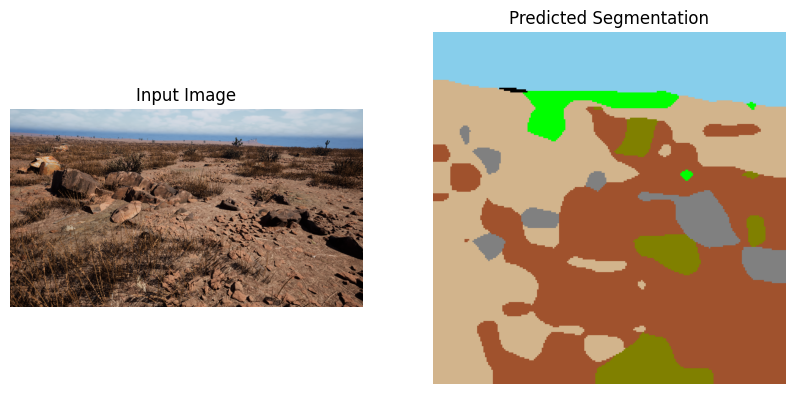

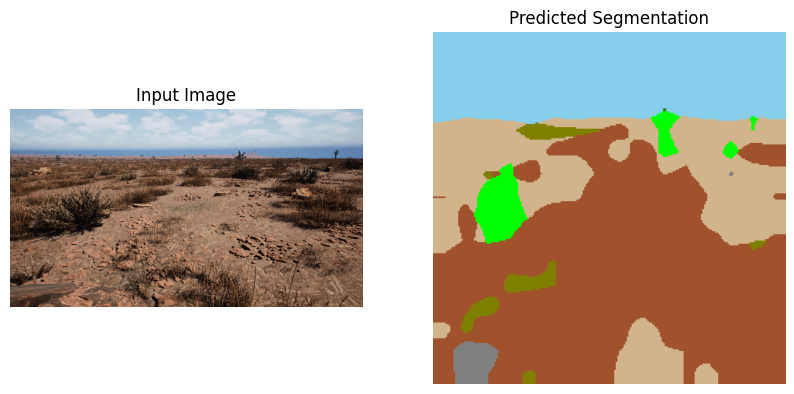

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os

input_dir = "/content/drive/MyDrive/Duality_project/Offroad_Segmentation_testImages/Color_Images"
pred_dir = "/content/predictions"

files = sorted(os.listdir(pred_dir))[:3]

for f in files:
    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    input_img = Image.open(os.path.join(input_dir, f))
    pred_img = Image.open(os.path.join(pred_dir, f))

    ax[0].imshow(input_img)
    ax[0].set_title("Input Image")
    ax[0].axis('off')

    ax[1].imshow(pred_img)
    ax[1].set_title("Predicted Segmentation")
    ax[1].axis('off')

    plt.show()